In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

from tqdm import tqdm

**Перед тем как начать выполнять задание, определитесь где вы будете обучать модель: на GPU или CPU.**

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

# Проблема затухания градиента

Рассмотрим проблему затухания градиента во время обучений неройнных сетей

**Залача 1:** Определите модель со следующей структурой:
1. Вход и выход заданы - линейными слоями (nn.Linear)
2. Скрытые слои - в виде линейных слоев в nn.ModuleList

In [3]:
# Класс модели:
class DeepMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, n_hidden):
        super(DeepMLP, self).__init__()
        self.input_layer = nn.Linear(input_size, hidden_size)
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_size, hidden_size) for _ in range(n_hidden)])
        self.output_layer = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.input_layer(x)
        for hidden_layer in self.hidden_layers:
            x = F.sigmoid(hidden_layer(x))
        x = self.output_layer(x)
        return x


**Вопрос:** Сколько параметров (весов) будет иметь эта модель, если инициализировать ее следующие аргументами:

input_size=3, 
hidden_size=6,
output_size=7,
n_hidden=1

**Пример ответа:** `123`

In [4]:
model = DeepMLP(input_size=3, hidden_size=6, output_size=7, n_hidden=1)
answer = sum(p.numel() for p in model.parameters())
answer

115

**Задача 2:** Вычислите среднее по градиенту в первом скрытом (!!!) слое.

**Вопрос:** Каково это значение?

**Пример ответа:** `1.2`

In [5]:
torch.manual_seed(42)

model = DeepMLP(28 * 28, 6, 7, 1)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
optimizer.zero_grad()
out = model(torch.rand((1, 28 * 28)))
loss = criterion(out, torch.rand((1, )).long())

loss.backward()

In [6]:
answer = model.hidden_layers[0].weight.grad.mean().item()
answer

0.001038502436131239

Теперь попробуйте обучить небольшую модель состоящую всего-лишь из трех скрытых слоев.

**Задача 3:** Создайте объект класса модели DeepMLP

In [7]:
torch.manual_seed(42)

# Инициализация модели, лосс функции и оптимайзера:
input_size = 28 * 28 # MNIST image size
hidden_size = 32
output_size = 10
n_hidden=3          # небольшая модель всего из трех скрытых слоев
model = DeepMLP(input_size, hidden_size, output_size, n_hidden).to(device)

**Вопрос:** Какова сумма всех выходов модели для случайного входного тензора test_data?

**Пример ответа:** `1.234`

In [8]:
test_data = torch.rand((1, 28*28)).to(device)

answer = model(test_data).sum().item()
answer

-0.5515778660774231

Теперь попробуем имплементировать цикл обучения и затем обучить модель на датасете MNIST. Но для начала давайте скачаем и подготовим этот датасет для обучения:

In [9]:
# Загрузка и подготовка датасета MNIST:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

 28%|██▊       | 2818048/9912422 [00:03<00:08, 804015.81it/s]

 29%|██▉       | 2916352/9912422 [00:03<00:10, 697075.62it/s]

 31%|███       | 3080192/9912422 [00:04<00:08, 828644.41it/s]

 32%|███▏      | 3178496/9912422 [00:04<00:08, 751583.22it/s]

 33%|███▎      | 3276800/9912422 [00:04<00:14, 462010.38it/s]

...

Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw



Failed to download (trying next):
HTTP Error 404: Not Found



  0%|          | 0/4542 [00:00<?, ?it/s]

100%|██████████| 4542/4542 [00:00<00:00, 2566073.38it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [10]:
# Опишем цикл обучения:
def train(model, trainloader, criterion, optimizer):
  torch.manual_seed(42)

  model.train()

  fc_gradients = []

  for step, data in tqdm(enumerate(trainloader), total=len(trainloader)):
      inputs, labels = data
      inputs, labels = inputs.to(device), labels.to(device)

      optimizer.zero_grad()
      outputs = model(inputs)
      loss = criterion(outputs, labels)
      
      loss.backward()
      optimizer.step()

      if step % 10 == 0:
        print(f'Step: {step}, Loss: {loss}')

      fc_gradients.append(model.hidden_layers[0].weight.grad.mean().item())  # <------ код из решения задачи 2

  return fc_gradients

In [11]:
# Теперь обучим модель:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

_ = train(model, trainloader, criterion, optimizer)

  5%|███████▉                                                                                                                                         | 51/938 [00:00<00:03, 260.89it/s]

Step: 0, Loss: 2.2937896251678467
Step: 10, Loss: 2.2889366149902344
Step: 20, Loss: 2.291050672531128
Step: 30, Loss: 2.1546096801757812
Step: 40, Loss: 2.016484022140503
Step: 50, Loss: 1.8273580074310303
Step: 60, Loss: 1.6764966249465942


 12%|█████████████████▋                                                                                                                              | 115/938 [00:00<00:02, 295.32it/s]

Step: 70, Loss: 1.5579310655593872
Step: 80, Loss: 1.4463380575180054
Step: 90, Loss: 1.5866329669952393
Step: 100, Loss: 1.327434778213501
Step: 110, Loss: 1.364395260810852
Step: 120, Loss: 1.170077919960022
Step: 130, Loss: 1.093766689300537


 19%|███████████████████████████▊                                                                                                                    | 181/938 [00:00<00:02, 309.16it/s]

...

Step: 840, Loss: 0.6188716292381287
Step: 850, Loss: 0.9044361114501953
Step: 860, Loss: 0.5665998458862305
Step: 870, Loss: 0.6321728229522705
Step: 880, Loss: 0.6785416007041931
Step: 890, Loss: 0.7917211055755615
Step: 900, Loss: 0.6847233176231384


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [00:03<00:00, 309.77it/s]

Step: 910, Loss: 0.6274378299713135
Step: 920, Loss: 0.7512227892875671
Step: 930, Loss: 0.6239621043205261


100%|██████████| 938/938 [00:03<00:00, 302.12it/s]

Step: 930, Loss: 0.6239621043205261


Как вы можете видеть, модель сходится, хотя и не очень хорошо. Вы должны получить лосс в диапазоне 0.5-0.9. Низкая производительность модели обусловлена тем, что трех скрытых слоев недостаточно чтобы хорошо обучить эту модель классифицировать MNIST датасет.

Теперь попробуйте увеличить количество скрытых слоев до 10 и обучить модель еще раз.

**Задача 4:** Увеличьте число скрытых слоев до 10.

In [12]:
torch.manual_seed(42)

# Инициализация модели, лосс функции и оптимайзера:
input_size = 28 * 28 # MNIST image size
hidden_size = 32
output_size = 10
n_hidden = 10
model = DeepMLP(input_size, hidden_size, output_size, n_hidden).to(device)

**Вопрос:** Посчитайте и выведите количество скрытых слоев модели.

**Пример ответа:** `3`

In [13]:
answer = len(model.hidden_layers)
answer

10

In [14]:
# Обучите модель еще раз:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

fc_gradients = train(model, trainloader, criterion, optimizer)

  0%|                                                                                                                                                           | 0/938 [00:00<?, ?it/s]

Step: 0, Loss: 2.3116233348846436


  7%|█████████▍                                                                                                                                       | 61/938 [00:00<00:02, 293.45it/s]

Step: 10, Loss: 2.2927772998809814
Step: 20, Loss: 2.328972816467285
Step: 30, Loss: 2.3101611137390137
Step: 40, Loss: 2.3166165351867676
Step: 50, Loss: 2.334524154663086
Step: 60, Loss: 2.3023855686187744
Step: 70, Loss: 2.3015944957733154


 13%|███████████████████▏                                                                                                                            | 125/938 [00:00<00:02, 306.73it/s]

...

Step: 780, Loss: 2.292786121368408
Step: 790, Loss: 2.2951321601867676
Step: 800, Loss: 2.2958858013153076
Step: 810, Loss: 2.3131911754608154
Step: 820, Loss: 2.3094000816345215
Step: 830, Loss: 2.3140485286712646
Step: 840, Loss: 2.3108716011047363


 95%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████       | 893/938 [00:02<00:00, 313.64it/s]

Step: 850, Loss: 2.3054323196411133
Step: 860, Loss: 2.3024682998657227
Step: 870, Loss: 2.2862768173217773
Step: 880, Loss: 2.297034978866577
Step: 890, Loss: 2.303971529006958
Step: 900, Loss: 2.301696300506592
Step: 910, Loss: 2.2977375984191895


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [00:03<00:00, 311.46it/s]

Step: 920, Loss: 2.2961878776550293
Step: 930, Loss: 2.297501564025879


Как вы можете видеть, лосс прекратил уменьшаться. Почему так произошло? Давайте визуализируем градиент для первого скрытого слоя (который записан в переменную fc_gradients; остальные скрытые слои будут иметь похожий градиена, так что опустим их).

/tmp/ipykernel_40729/2019969697.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


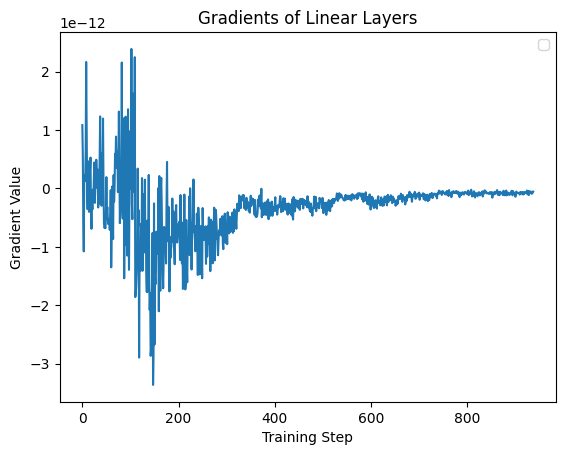

In [15]:
# Визуализируйте градиент:
plt.plot(fc_gradients)
plt.legend()
plt.title("Gradients of Linear Layers")
plt.xlabel("Training Step")
plt.ylabel("Gradient Value")
plt.show()

Как видите, после примерно 300 итерации градиент начал *затухать*, что означает, что веса скрытых слоев перестали обучаться. По этой причине лосс и перестал уменьшаться, т.к. градиент стал слишком мал чтобы влиять на веса слоев.

Глубокие модели (с большим числом скрытых слоев) подвержены проблеме затухания градиента, что приводит к тому, что такие модели не могут обучаться эффективно. 

Одна из причин этого (в этом примере) это использования sigmoid в качестве функции активации. Давайте изменим функцию активации на ReLU и переобучим модель еще раз.

**Задача 5:** Замените sigmoid на ReLU

In [16]:
# Замените sigmoid на ReLU:
class DeepMLP_ReLU(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, n_hidden):
    super(DeepMLP_ReLU, self).__init__()
    self.input_layer = nn.Linear(input_size, hidden_size)
    self.hidden_layers = nn.ModuleList([nn.Linear(hidden_size, hidden_size) for _ in range(n_hidden)])
    self.output_layer = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    x = x.view(-1, 28 * 28)
    x = self.input_layer(x)
    for hidden_layer in self.hidden_layers:
        x = F.relu(hidden_layer(x))
    x = self.output_layer(x)
    return x


**Вопрос:** Посчитайте и выведите сумму всех выходов модели для рандмного входного тензора test_input

**Пример ответа:** `0.234`

In [17]:
# Инициализируйте модель с ReLU:
torch.manual_seed(42)

input_size = 28 * 28
hidden_size = 32
output_size = 10
n_hidden=10
model_relu = DeepMLP_ReLU(input_size, hidden_size, output_size, n_hidden).to(device)

In [18]:
torch.manual_seed(42)
test_input = torch.rand(1, 28*28).to(device)
answer = model_relu(test_input).sum().item()
answer

-0.2832258343696594

In [19]:
# Обучите модель с ReLU:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_relu.parameters(), lr=0.01)

fc_gradients = train(model_relu, trainloader, criterion, optimizer)

  7%|█████████▌                                                                                                                                       | 62/938 [00:00<00:02, 305.29it/s]

Step: 0, Loss: 2.3037009239196777
Step: 10, Loss: 2.2954559326171875
Step: 20, Loss: 2.302825689315796
Step: 30, Loss: 2.304784059524536
Step: 40, Loss: 2.269399404525757
Step: 50, Loss: 2.288843870162964
Step: 60, Loss: 2.1865103244781494


 13%|███████████████████▎                                                                                                                            | 126/938 [00:00<00:02, 310.74it/s]

Step: 70, Loss: 1.9980804920196533
Step: 80, Loss: 1.9333523511886597
Step: 90, Loss: 1.849602460861206
Step: 100, Loss: 1.7814520597457886
Step: 110, Loss: 1.8841309547424316
Step: 120, Loss: 1.646066665649414
Step: 130, Loss: 1.5646380186080933


 20%|█████████████████████████████▏                                                                                                                  | 190/938 [00:00<00:02, 313.18it/s]

...

Step: 830, Loss: 1.0275778770446777
Step: 840, Loss: 1.0594466924667358
Step: 850, Loss: 1.5324978828430176
Step: 860, Loss: 0.9768964648246765
Step: 870, Loss: 0.9116690754890442
Step: 880, Loss: 1.2200366258621216
Step: 890, Loss: 2.117037057876587


 96%|█████████▋| 904/938 [00:02<00:00, 305.33it/s]

100%|█████████▉| 935/938 [00:03<00:00, 301.85it/s]

100%|██████████| 938/938 [00:03<00:00, 302.46it/s]

Step: 900, Loss: 2.235046625137329
Step: 910, Loss: 2.1179959774017334
Step: 920, Loss: 1.8307925462722778
Step: 930, Loss: 1.9335452318191528


/tmp/ipykernel_40729/2806989764.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


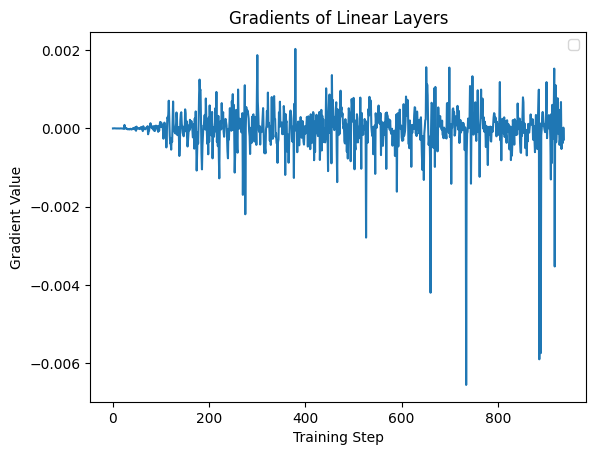

In [20]:
# Визуализируйте градинте:
plt.plot(fc_gradients)
plt.legend()
plt.title("Gradients of Linear Layers")
plt.xlabel("Training Step")
plt.ylabel("Gradient Value")
plt.show()

Вы должны получить лосс в диапазоне 1.3-1.6. Проблема затухания градиента должна уменьшится, но не решиться полностью. Обучение глубоких нейронных сетей является нетривиальной задачей!

# Проблема взрыва градиента

Это проблема противоположна предыдущей. Вместо стремления градиента к 0, и потери способности изменять веса слоев (а значит и обучаться), градиент может "взорваться" (его значения стремятся к большим числам), что приводит к очень большим и резким изменениям весов модели, не позволяя модели сходиться.

**Задача 6:** Инициализируйте модель еще раз со следующими входными параметрами.

In [21]:
torch.manual_seed(42)

# Инициализация модели, лосс функции и оптимайзера:
input_size = 28 * 28 # MNIST image size
hidden_size = 512
output_size = 10
n_hidden=20
model = DeepMLP(input_size, hidden_size, output_size, n_hidden).to(device)

**Вопрос:** Посчитайте и выведите сумму всех выходов модели для рандмного входного тензора test_input (да да, еще раз)

**Пример ответа:** `0.234`

In [22]:
torch.manual_seed(42)
test_input = torch.rand(1, 28*28).to(device)
answer = model(test_input).sum().item()
answer

-0.9367366433143616

In [23]:
# Обучите модель еще раз:
torch.manual_seed(42)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

fc_gradients = train(model, trainloader, criterion, optimizer)

  6%|████████▉                                                                                                                                        | 58/938 [00:00<00:03, 287.36it/s]

Step: 0, Loss: 2.370612144470215
Step: 10, Loss: 2.319352149963379
Step: 20, Loss: 2.384559392929077
Step: 30, Loss: 2.322371482849121
Step: 40, Loss: 2.3334951400756836
Step: 50, Loss: 2.335846185684204
Step: 60, Loss: 2.337700366973877


 13%|██████████████████▍                                                                                                                             | 120/938 [00:00<00:02, 298.66it/s]

Step: 70, Loss: 2.294940948486328
Step: 80, Loss: 2.3135998249053955
Step: 90, Loss: 2.3037660121917725
Step: 100, Loss: 2.3035049438476562
Step: 110, Loss: 2.311680316925049
Step: 120, Loss: 2.2950565814971924
Step: 130, Loss: 2.2916624546051025


 19%|███████████████████████████▉                                                                                                                    | 182/938 [00:00<00:02, 300.42it/s]

...

Step: 810, Loss: 2.3135786056518555
Step: 820, Loss: 2.307420015335083
Step: 830, Loss: 2.3165266513824463
Step: 840, Loss: 2.305375337600708
Step: 850, Loss: 2.3068716526031494
Step: 860, Loss: 2.3002524375915527
Step: 870, Loss: 2.2848074436187744


 96%|█████████▌| 902/938 [00:02<00:00, 306.24it/s]

 99%|█████████▉| 933/938 [00:03<00:00, 306.78it/s]

100%|██████████| 938/938 [00:03<00:00, 302.82it/s]

Step: 880, Loss: 2.302747964859009
Step: 890, Loss: 2.299281597137451
Step: 900, Loss: 2.3038330078125
Step: 910, Loss: 2.2965760231018066
Step: 920, Loss: 2.298959970474243
Step: 930, Loss: 2.2944693565368652


/tmp/ipykernel_40729/2019969697.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


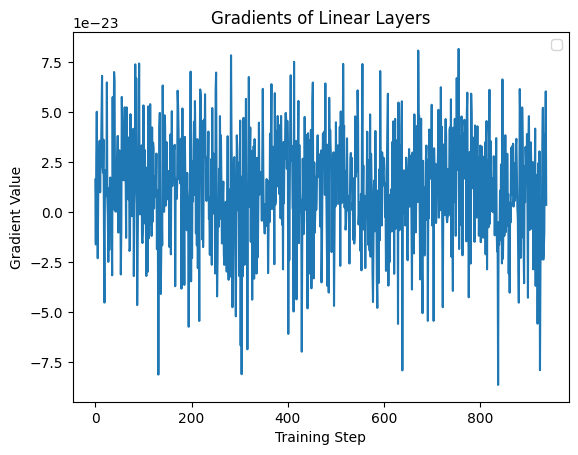

In [24]:
# Визуализируйте градиент:
plt.plot(fc_gradients)
plt.legend()
plt.title("Gradients of Linear Layers")
plt.xlabel("Training Step")
plt.ylabel("Gradient Value")
plt.show()

Как видите, магнитуда градиента стала слишком большой, что приводит к тому, что модель не может сойтись (достичь минимума).

# ResNet

Теперь давайте попробуем реализовать модель ResNet. Ее авторы нашли способ как бороться с проблемой затухания градиента в глубоких сетях используя так называемые shortcut (или residual) связи между слоями.

**Задача 7:** Определите Residual Block

In [25]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride), nn.BatchNorm2d(out_channels))

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.shortcut(x)
        out = F.relu(out)
        return out

**Вопрос:** Посчитайте и выведите сумму выходов ResidualBlock(10,10) для рандомного входного тензора test_input.

**Пример ответа:** `1.234`

In [26]:
torch.manual_seed(42)
test_input = torch.rand((1, 10, 3, 28*28))
res_block = ResidualBlock(10, 10)
answer = res_block(test_input).sum()
answer

tensor(16789.0645, grad_fn=<SumBackward0>)

**Задача 8:** Теперь определите модель ResNet, состоящую из нескольких ResidualBlock

In [27]:
class ResNet(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1)
        self.layer1 = self._make_layer(64, 64, 2)
        self.layer2 = self._make_layer(64, 128, 2)
        self.layer3 = self._make_layer(128, 256, 2)
        self.fc = nn.Linear(2304, num_classes)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride=1):
        layers = []
        for i in range(num_blocks):
            if i == 0:
                layers.append(ResidualBlock(in_channels, out_channels, stride))
            else:
                layers.append(ResidualBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.conv1(x))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.avg_pool2d(out, 8)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

**Вопрос:** Посчитайте и выведите количество параметров (весов) этой ResNet модели

**Пример ответа:** `43242`

In [28]:
model = ResNet()
answer = sum(p.numel() for p in model.parameters())
answer

2799114

In [29]:
# Инициализируем объект класса модели ResNet, а также лосс функцию и оптимайзер:
torch.manual_seed(42)

model = ResNet().to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [30]:
# Теперь обучите эту модель:
torch.manual_seed(42)

model.train()

fc_gradients = []

for step, data in tqdm(enumerate(trainloader), total=len(trainloader)):
    inputs, labels = data
    inputs, labels = inputs.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    
    loss.backward()
    optimizer.step()

    if step % 10 == 0:
      print(f'Step: {step}, Loss: {loss}')

    fc_gradients.append(model.fc.weight.grad.mean().item())

  0%|▋                                                                                                                                                  | 4/938 [00:00<00:59, 15.80it/s]

Step: 0, Loss: 2.4626097679138184


  1%|██                                                                                                                                                | 13/938 [00:00<00:41, 22.37it/s]

Step: 10, Loss: 4.6844048500061035


  3%|███▉                                                                                                                                              | 25/938 [00:01<00:37, 24.12it/s]

...

 99%|█████████▉| 931/938 [00:38<00:00, 23.61it/s]

100%|█████████▉| 934/938 [00:38<00:00, 23.53it/s]

Step: 930, Loss: 0.07500144094228745


100%|█████████▉| 937/938 [00:38<00:00, 23.56it/s]

100%|██████████| 938/938 [00:39<00:00, 24.04it/s]

Как можете видеть, лосс продолжает уменьшаться. Теперь попробуйте визиулизировать градиент накопленный в переменной fc_gradients

/tmp/ipykernel_40729/2019969697.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


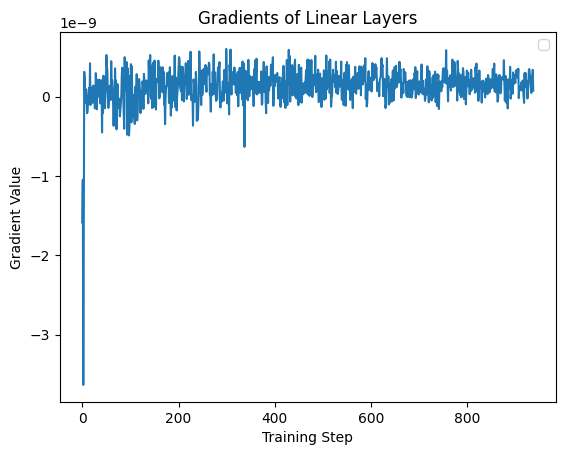

In [31]:
# Визуализируйте градиент:
plt.plot(fc_gradients)
plt.legend()
plt.title("Gradients of Linear Layers")
plt.xlabel("Training Step")
plt.ylabel("Gradient Value")
plt.show()

Теперь градиент кажется достаточно стабильным, и это позволяет ResNet модели обучаться лучше предыдущей модели, которая была подвержена проблеме затухания градента. Таким способом ResNet стала SOTA моделью в 2015 году и выиграла ImageNet competition.

Наконец, давайте сохраним параметры (веса) обученной модели чтобы переиспользовать их позже:

In [32]:
checkpoint_path = './mnist_checkpoint.pth'
torch.save(model.state_dict(), checkpoint_path)

# Transfer Learning

Перед тем как мы перейдем к технике обучения называемой Transfer Learning, давайте сперва протестируем нашу модель на тестовой подвыборке датасета MNIST. Чтобы сделать это, вам необходимо скачать тестовую подвыборку схожим образом, как вы уже скачали подвыборку для обучения с тем отличием, что нужно изменить параметр `train=False`:

In [33]:
# Загрузите тестовую подвыборку датасета MNIST:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

Теперь нам нужно имплементировать функцию для тестирования модели, в которой мы будем считать точность (accuracy) нашей модели (т.е. процент правильных предсказаний):

In [34]:
def test(model, dataloader):
  model.eval()

  with torch.no_grad():
    correct = 0

    for step, data in tqdm(enumerate(dataloader), total=len(dataloader)):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        correct += (outputs.argmax(1) == labels).type(torch.float).sum().item()
        
    accuracy = correct/len(dataloader.dataset)

    return accuracy

Теперь загрузите ранее сохраненные параметры (веса) обученной ResNet модели:

**Задача 9:** Посчитайте точность модели на тесте.

In [35]:
model = ResNet()
model.load_state_dict(torch.load(checkpoint_path))
model = model.to(device)

/tmp/ipykernel_40729/2656501242.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path))


**Вопрос:** Посчитайте и выведите точность модели на тестовой выборке MNIST.

**Пример ответа:** `22.45`

In [36]:
accuracy = test(model, testloader)
print(f"\nMNIST test accuracy: {100*accuracy}%")  

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:02<00:00, 72.72it/s]


MNIST test accuracy: 97.03%


 29%|██▉       | 46/157 [00:00<00:01, 73.28it/s]

 34%|███▍      | 54/157 [00:00<00:01, 73.37it/s]

 39%|███▉      | 62/157 [00:00<00:01, 73.28it/s]

...

 85%|████████▌ | 134/157 [00:01<00:00, 72.98it/s]

 90%|█████████ | 142/157 [00:01<00:00, 73.02it/s]

 96%|█████████▌| 150/157 [00:02<00:00, 73.00it/s]

100%|██████████| 157/157 [00:02<00:00, 72.39it/s]


MNIST test accuracy: 97.71%


Вы должны получить точность примерно 96% или выше.

Теперь давайте попробуем загрузить другой датасет - CIFAR10, который состоит из 10 классов, но содержит изображения не рукописаных цифр, а объектов (horses, dogs, cars, и др.). Изображения имеют размер 32x32 и три цветовых канала (RGB). Поэтому нам также нужно изменить трансформации (transforms), чтобы изображения CIFAR10 соответствовали  изображениям MNIST (т.е. 28x28 в формате grayscale):

In [37]:
# Трансформации для датасета CIFAR10:
transform_cifar10 = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28,28)), 
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))])

# Выборка для обучения:
trainset_cifar10 = torchvision.datasets.CIFAR10(root='./data_cifar10', train=True, download=True, transform=transform_cifar10)
trainloader_cifar10 = torch.utils.data.DataLoader(trainset_cifar10, batch_size=64, shuffle=True, num_workers=2)

# Выборка для тестирования:
testset_cifar10 = torchvision.datasets.CIFAR10(root='./data_cifar10', train=False, download=True, transform=transform_cifar10)
testloader_cifar10 = torch.utils.data.DataLoader(testset_cifar10, batch_size=64, shuffle=False, num_workers=2)

Files already downloaded and verified
Files already downloaded and verified


  0%|          | 131072/170498071 [00:01<38:29, 73755.39it/s]

  0%|          | 163840/170498071 [00:02<38:36, 73524.59it/s]

  0%|          | 196608/170498071 [00:02<38:37, 73493.28it/s]

  0%|          | 229376/170498071 [00:03<38:34, 73572.67it/s]

...

100%|█████████▉| 170459136/170498071 [40:07<00:00, 79609.96it/s]

100%|█████████▉| 170491904/170498071 [40:07<00:00, 80044.91it/s]

100%|██████████| 170498071/170498071 [40:07<00:00, 70814.22it/s]

Extracting ./data_cifar10/cifar-10-python.tar.gz to ./data_cifar10


Files already downloaded and verified


Теперь протестируйте ранее обученную ResNet модель на тестовой выборке датасета CIFAR10 (пока переобучать модель не нужно!):

**Задача 10:** Протестируйте модель на тестовой выборке CIFAR10

**Вопрос:** Посчитайте и выведите точность модели на тесте

**Пример ответа:** `22.45`

In [38]:
accuracy = test(model, testloader_cifar10)
print(f"\nTest accuracy: {100*accuracy}%")  

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:02<00:00, 73.92it/s]


Test accuracy: 11.25%


 29%|██▊       | 45/157 [00:00<00:01, 74.27it/s]

 34%|███▍      | 53/157 [00:00<00:01, 74.98it/s]

 39%|███▉      | 61/157 [00:00<00:01, 75.43it/s]

...

 85%|████████▍ | 133/157 [00:01<00:00, 76.16it/s]

 90%|████████▉ | 141/157 [00:01<00:00, 76.14it/s]

 95%|█████████▍| 149/157 [00:02<00:00, 76.19it/s]

100%|██████████| 157/157 [00:02<00:00, 74.35it/s]


Test accuracy: 9.69%


Как видите, точность на CIFAR10 не очень большая (около 10%). И это не удивительно, ведь мы обучали нашу ResNet модель на другом датасете (MNIST).

Теперь давайте заморозим все слои за исключением последнего (т.е. слоя классификации):

**Задача 11:** Заморозьте слои модели кроме последнего

In [39]:
for param in model.parameters():
    param.requires_grad = False              # отключаем градиент (т.е. "замораживаем" слои)
    
mnist_fc = model.fc                          # Сохраняем в переменную слой классификации MNIST
in_features = model.fc.in_features         
model.fc = torch.nn.Linear(in_features, 10)  # Создаем новый слой классификации для CIFAR10
model.fc = model.fc.cuda()

**Вопрос:** Посчитайте и выведите количество параметров (весов) в замороженных слоях

**Пример ответа:** `224513`

In [40]:
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
frozen_params

2776064

**Задача 12:** Обучите только последний слой модели на датасете CIFAR10 (все остальные слои должны быть заморожены)

In [41]:
torch.manual_seed(42)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

model.train()

for step, data in tqdm(enumerate(trainloader_cifar10), total=len(trainloader_cifar10)):
    inputs, labels = data
    inputs, labels = inputs.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    if step % 10 == 0:
      print(f'Step: {step}, Loss: {loss}')

  2%|██▉                                                                                                                                               | 16/782 [00:00<00:10, 73.44it/s]

Step: 0, Loss: 2.330970287322998
Step: 10, Loss: 2.3243093490600586


  4%|█████▉                                                                                                                                            | 32/782 [00:00<00:10, 73.31it/s]

Step: 20, Loss: 2.238206386566162
Step: 30, Loss: 2.3451778888702393


  7%|██████████▍                                                                                                                                       | 56/782 [00:00<00:09, 72.92it/s]

...

 99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉ | 776/782 [00:10<00:00, 71.23it/s]

Step: 760, Loss: 2.024465799331665
Step: 770, Loss: 1.7335526943206787


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 782/782 [00:10<00:00, 71.57it/s]

Step: 780, Loss: 2.085937023162842


Step: 780, Loss: 2.072021007537842


**Вопрос:** Посчитайте точность на тестовой выборке CIFAR10

**Пример ответа:** `32.45`

In [42]:
accuracy = test(model, testloader_cifar10)
print(f"\nTest accuracy: {100*accuracy}%")   

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:02<00:00, 71.54it/s]


Test accuracy: 36.24%


 30%|██▉       | 47/157 [00:00<00:01, 74.66it/s]

 35%|███▌      | 55/157 [00:00<00:01, 74.86it/s]

 40%|████      | 63/157 [00:00<00:01, 74.99it/s]

...

 86%|████████▌ | 135/157 [00:01<00:00, 75.52it/s]

 91%|█████████ | 143/157 [00:01<00:00, 75.57it/s]

 96%|█████████▌| 151/157 [00:02<00:00, 75.63it/s]

100%|██████████| 157/157 [00:02<00:00, 74.78it/s]


Test accuracy: 35.57%


Как можете видеть, точность модели выросла до примерно 35%. Мы обучили только последний слой (классификации), а остальная часть сети осталось нетронутой (т.е. остальные слои обучены на датасете MNIST). Эта техника обучения и называется Transfer Learning.

Теперь протестируйте эту модель еще раз на тестовой выборке MNIST:

In [43]:
accuracy = test(model, testloader)
print(f"\nMNIST test accuracy: {100*accuracy}%")  

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:02<00:00, 72.59it/s]


MNIST test accuracy: 12.4%


 29%|██▉       | 46/157 [00:00<00:01, 74.56it/s]

 34%|███▍      | 54/157 [00:00<00:01, 74.87it/s]

 39%|███▉      | 62/157 [00:00<00:01, 75.05it/s]

...

 85%|████████▌ | 134/157 [00:01<00:00, 75.54it/s]

 90%|█████████ | 142/157 [00:01<00:00, 75.42it/s]

 96%|█████████▌| 150/157 [00:02<00:00, 75.51it/s]

100%|██████████| 157/157 [00:02<00:00, 74.58it/s]


MNIST test accuracy: 6.140000000000001%


Как вы можете видеть, точность упала ниже 10%, поскольку последний слой классификации теперь обучен на CIFAR10 датасете. Это называется "катастрофическим забыванием" (catastrophic forgetting). Катастрофическое забывание это тенденация нейронной сети забывать предыдущие обученные знания когда она обучается новой информации.

Наконец, давайте вернем назад ранее сохраненный слой классификации обученный на MNIST и протестируем еще раз:

**Задача 13:** Верните последний слой mnist_fc и проведите финальный тест на тестовых выборках MNIST и CIFAR10

**Вопрос:** Посчитайте и выведите точность на тестовых выборках MNIST и CIFAR10

**Пример ответа:** 
`CIFAR test accuracy: 9.45`
`MNIST test accuracy: 51.68`

In [44]:
model.fc = mnist_fc                        # верните в модель слой классификации обученный на MNIST
model.fc = model.fc.cuda()                # Перенесем на cuda

accuracy = test(model, testloader_cifar10)
print(f"\nCIFAR test accuracy: {100*accuracy}%")

accuracy = test(model, testloader)
print(f"\nMNIST test accuracy: {100*accuracy}%")  

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:02<00:00, 71.51it/s]


CIFAR test accuracy: 8.780000000000001%



100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:02<00:00, 72.28it/s]


MNIST test accuracy: 77.83%


 50%|█████     | 79/157 [00:01<00:01, 75.07it/s]

...

 85%|████████▌ | 134/157 [00:01<00:00, 75.12it/s]

 90%|█████████ | 142/157 [00:01<00:00, 75.10it/s]

 96%|█████████▌| 150/157 [00:02<00:00, 75.17it/s]

100%|██████████| 157/157 [00:02<00:00, 74.12it/s]


MNIST test accuracy: 89.02%
